In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import datetime as dt
import random
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore
import numpy as np, pandas as pd
from tqdm import tqdm
# Custom functions for alpha calculations
import importlib.util
import sys
import json
import os
from WorldQuant_alpha101_code.alphas import *
from WorldQuant_alpha101_code.test_alphas import *

# configs
CLIPPING_VALUE = 1e6
RANDOM_SEED = 42
HORIZON = 20

#### Part 0: Obtaining stock data

In [72]:
tickers = ['XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV']
industries = {'XLB': 'Buildings',
             'XLE': 'Energy',
             'XLF': 'Financials',
             'XLI': 'Industrials',
             'XLK': 'Technology',
             'XLP': 'Consumer Staples',
             'XLU': 'Utilities',
             'XLV': 'Healthcare'
             }
start_date = dt.datetime(2000,1,1)
end_date = dt.datetime(2025,10,1)

stock_data = yf.download(tickers, start_date, end_date,auto_adjust=False)
tickers = stock_data['Close'].columns.tolist()

[*********************100%***********************]  8 of 8 completed


In [3]:
stock_data = stock_data.drop(columns=['Close']).rename(columns={'Adj Close':'Close'})

In [4]:
# Calculate returns for each ticker separately
returns = stock_data['Close'].pct_change()

# Add as new top-level column
for ticker in stock_data['Close'].columns:
    stock_data[('Returns', ticker)] = returns[ticker]

In [5]:
nav_dict = {}
for ticker in tickers:
    df = pd.read_excel(f'ETF data/navhist-us-en-{ticker.lower()}.xlsx',
                                     skiprows=3)
    df = df[['Date','Shares Outstanding']]
    df = df[~(df['Shares Outstanding'].isnull()) & ~(df['Shares Outstanding']=='-')]
    df['Date'] = pd.to_datetime(df['Date'])
    df['Shares Outstanding'] = df['Shares Outstanding'].astype(float)
    df = df.set_index('Date')

    nav_dict[ticker] = df.sort_index(ascending=True).copy()

In [6]:
for ticker, df in nav_dict.items():
    stock_data[('Shares Outstanding', ticker)] = df['Shares Outstanding']
stock_data['Close']

Ticker,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV
Date,,,,,,,,
2000-01-03,14.595760,13.513024,11.186879,18.187748,41.366714,12.305084,11.186381,20.612185
2000-01-04,14.455250,13.258661,10.697832,17.685265,39.268066,11.958584,10.848944,20.144453
2000-01-05,15.052426,13.608415,10.613775,17.606436,38.685101,12.169866,11.122708,19.963724
2000-01-06,15.438841,14.133033,11.079901,17.842901,37.402599,12.398050,11.103615,20.027508
2000-01-07,15.430052,14.284058,11.263293,18.522726,38.055515,13.184014,11.199114,20.272011
...,...,...,...,...,...,...,...,...
2025-09-24,88.980003,90.339996,53.610001,152.250000,278.489990,78.519997,86.250000,136.389999
2025-09-25,87.820000,91.150002,53.470001,151.220001,278.000000,77.769997,85.419998,134.130005
2025-09-26,88.839996,91.989998,53.860001,152.580002,278.839996,77.959999,86.809998,135.500000


In [7]:
for ticker in tickers:
    stock_data[('Market_Cap', ticker)] = stock_data[('Close', ticker)] * stock_data[('Shares Outstanding', ticker)]
stock_data = stock_data.dropna(subset=[('Market_Cap', ticker) for ticker in tickers], how='all')

#### Part 1: Factor construction

Start with raw stock data. Compute 82 of 101 alphas

- Core Alpha101-style technical factors

In [8]:
# Alphas = Alphas(stock_data)

### Dealing with NaNs in Alphas
#### Source of NaNs
a. Rolling window
    - these occur when there is a rolling window that results in NaNs at the start of the alpha created

b. Systematic NaNs
    - these occur due to systematic computation of the formula that results in NaNs happening sporadically. 
    - Need to further investigate these

In [9]:
def build_factor_table_v3(stock_data, alpha_methods, Alphas_class, industry_map, gap=1, horizon=21):
    """
    Build a long-format factor table with multiple timing windows.
    
    Parameters:
    -----------
    stock_data : pd.DataFrame
        Multi-level DataFrame with OHLCV data
    alpha_methods : list
        List of alpha method names (e.g., ['alpha001', 'alpha002'])
    Alphas_class : class
        The Alphas class (not an instance!)
    industry_map : dict
        Mapping of ticker -> industry
    gap : int
        Gap period before measuring returns
    horizon : int
        Forward return horizon
    
    Returns:
    --------
    pd.DataFrame
        Factor table with columns: alpha features, market_cap, industry, forward_return
    """
    
    # Define window scaling configurations
    window_configs = {
        'short': 0.75,   # 50% of original windows
        'base': 1.0,    # Original windows
        'long': 1.75,    # 200% of original windows
    }
    
    # All unique windows used across alphas (from your alphas.py)
    base_windows = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 18, 20, 21, 22, 
                    26, 30, 32, 37, 40, 50, 60, 100, 120, 180, 200, 220, 230, 240, 250]
    
    series_list = []
    
    print("\n" + "="*70)
    print("🔄 Calculating Alphas with Multiple Window Configurations")
    print("="*70 + "\n")
    
    for set_name, scale_factor in window_configs.items():
        print(f"\n📊 Processing '{set_name}' configuration (scale={scale_factor})...")
        
        # Create window mapping for this configuration
        windows = {
            f"w_{w}": max(1, int(round(w * scale_factor)))  # Scale and ensure >= 1
            for w in base_windows
        }
        
        # Create NEW instance with these windows
        alphas_instance = Alphas_class(stock_data, windows=windows)
        
        for method_name in tqdm(alpha_methods, desc=f'Alphas [{set_name}]'):
            try:
                alpha_func = getattr(alphas_instance, method_name)
                
                # Compute alpha
                alpha_df = alpha_func()
                
                # Clean output
                alpha_df = alpha_df.clip(lower=-CLIPPING_VALUE, upper=CLIPPING_VALUE)
                alpha_df = alpha_df.replace([np.inf, -np.inf], np.nan)
                alpha_df = alpha_df.fillna(alpha_df.rolling(252, min_periods=1).mean())

                # Flatten to (date, ticker) Series
                s = alpha_df.stack()
                s.name = f"{method_name}_{set_name}"
                series_list.append(s)
                
            except Exception as e:
                print(f"\n❌ {method_name} ({set_name}) failed: {e}")
    
    print("\n" + "="*70)
    print("✅ Alphas calculation complete!")
    
    # Combine all alpha factors into one DataFrame
    print("🔗 Combining all factors...")
    factors_df = pd.concat(series_list, axis=1)
    print(f"✅ Factors combined: {factors_df.shape}")
    
    # Add Market Cap and Industry
    print("📈 Adding market cap and industry...")
    factors_df['market_cap'] = stock_data['Market_Cap'].stack()
    factors_df['industry'] = factors_df.index.get_level_values('Ticker').map(industry_map)
    
    # Compute forward returns
    print(f"📊 Computing {horizon}-day forward returns (gap={gap})...")
    fwd = (stock_data['Close']
           .shift(-(gap + horizon)) / stock_data['Close'].shift(-gap) - 1).stack()
    factors_df['forward_return'] = fwd
    
    # Drop missing rows
    print("🧹 Cleaning data...")
    # keep_cols = [c for c in factors_df.columns if c.startswith("alpha")] + ['market_cap', 'forward_return']
    keep_cols = [c for c in factors_df.columns if c in ['market_cap', 'forward_return']]
    initial_rows = len(factors_df)
    factors_df = factors_df.dropna(how='any', subset=keep_cols)
    dropped_rows = initial_rows - len(factors_df)
    factors_df = factors_df.sort_index()
    
    print("\n" + "="*70)
    print("✅ Factor Table Complete!")
    print(f"   - Total features: {len([c for c in factors_df.columns if c.startswith('alpha')])}")
    print(f"   - Base alphas: {len(alpha_methods)}")
    print(f"   - Window configs: {len(window_configs)}")
    print(f"   - Final rows: {len(factors_df):,}")
    print(f"   - Dropped rows: {dropped_rows:,} ({100*dropped_rows/initial_rows:.1f}%)")
    print("="*70 + "\n")
    
    return factors_df

alpha_methods = [method for method in dir(Alphas) 
            if method.startswith('alpha') and method[5:].isdigit()]

In [10]:
factor_table = build_factor_table_v3(stock_data, alpha_methods, Alphas, industries, horizon=HORIZON)
                                                                            # changed horizon to 1 day to match Du paper

alpha_methods = [factor for factor in factor_table.columns if factor.startswith("alpha")]                                                                                                                                      


🔄 Calculating Alphas with Multiple Window Configurations


📊 Processing 'short' configuration (scale=0.75)...


Alphas [short]:  76%|███████▌  | 62/82 [00:30<00:10,  1.95it/s]/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
Alphas [short]: 100%|██████████| 82/82 [01:12<00:00,  1.13it/s]



📊 Processing 'base' configuration (scale=1.0)...


Alphas [base]:  76%|███████▌  | 62/82 [00:30<00:10,  1.95it/s]/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
Alphas [base]: 100%|██████████| 82/82 [01:13<00:00,  1.11it/s]



📊 Processing 'long' configuration (scale=1.75)...


Alphas [long]:  90%|█████████ | 74/82 [00:49<00:11,  1.39s/it]/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
Alphas [long]: 100%|██████████| 82/82 [01:13<00:00,  1.11it/s]



✅ Alphas calculation complete!
🔗 Combining all factors...
✅ Factors combined: (38920, 246)
📈 Adding market cap and industry...
📊 Computing 20-day forward returns (gap=1)...
🧹 Cleaning data...

✅ Factor Table Complete!
   - Total features: 246
   - Base alphas: 82
   - Window configs: 3
   - Final rows: 38,752
   - Dropped rows: 168 (0.4%)



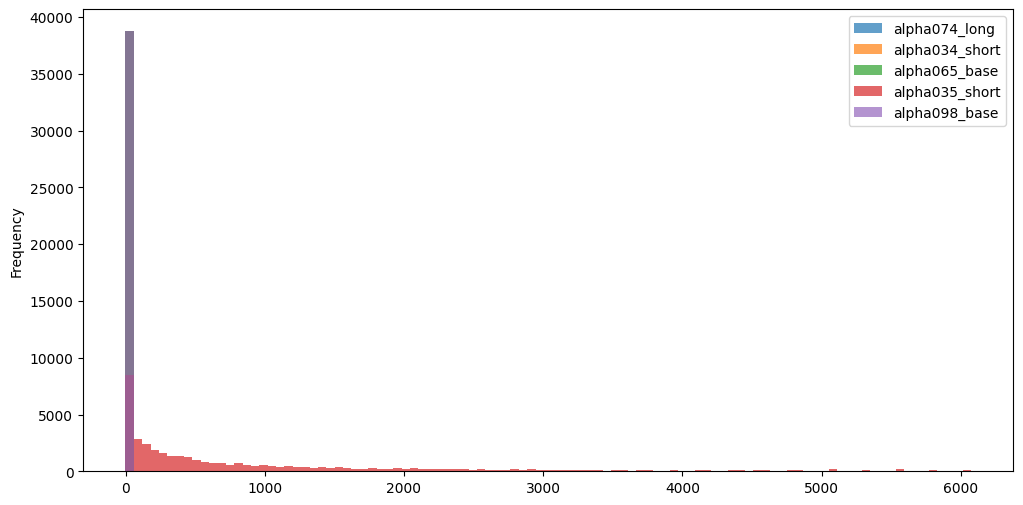

In [11]:
factor_table[random.sample(alpha_methods, 5)].plot(figsize=(12,6), kind='hist', bins=101, alpha=0.7);

In [12]:
len(alpha_methods)

246

Notes:
- Market capitalisation is included in the data pipeline even though it itself is not an alpha factor. Market cap represents firm size, which is one of the strongest systematic risk factors in asset pricing.
- If size is not controlled for, many factors will simply be disguised size effects (e.g. if momentum or liquidity factor loads heavily on small caps, it looks predictive, but the model would simply be leaning into the size bias - small caps having higher vol, higher momentum and lower liquidity).
- The eventual size neutralization in the pipeline is: Regressing each factor on log(MarketCap) and (log(MarketCap))<sup>2</sup> per date, then using residuals as the pure alpha.

# Measure baseline IC
## Function to compute information coefficient


In [27]:
def compute_ic(table, factor_col, forward_return_col='forward_return', method='spearman'):
    """
    Compute the Information Coefficient (IC) per date.

    The IC is the cross-sectional correlation between factor values and 
    forward returns for each date. It measures how well the factor predicts returns.

    Parameters
    ----------
    table : pd.DataFrame
        Must contain 'Date', factor_col, and forward_return_col columns.
    factor_col : str
        Column name of the (possibly neutralized) factor.
    forward_return_col : str, default='forward_return'
        Column name of forward returns.
    method : {'pearson', 'spearman'}, default='pearson'
        Correlation method to use.

    Returns
    -------
    pd.Series
        Series of IC values indexed by date.
    # """
    ic_series = {}
    for dt, s in table.groupby('Date'):
        s = s[[factor_col, forward_return_col]].dropna()
        if len(s) < 5:
            # print(f"Not enough data to compute IC for date {dt}. Required at least 5, got {len(s)}.")
            ic_series[dt] = np.nan
            continue
        
        # Check if either column has zero variance
        if s[factor_col].std() == 0:
            # print(f"Zero variance in factor '{factor_col}' on date {dt}. Cannot compute IC.")
            ic_series[dt] = np.nan
            continue
            
        if method == 'spearman':
            rho = s[factor_col].rank().corr(s[forward_return_col].rank())
        else:
            rho = s[factor_col].corr(s[forward_return_col])
        ic_series[dt] = rho
    return pd.Series(ic_series).sort_index()


In [14]:
# factor_table.groupby('Date').size()
# factor_table.loc['2025-07-21'].isnull().sum()
null_counts = factor_table.loc['2025-07-21'].isnull().sum()
columns_with_nulls = null_counts[null_counts > 0]
print(columns_with_nulls)

Series([], dtype: int64)


In [15]:
(factor_table.isnull().sum().sort_values(ascending=False) / len(factor_table)).head(20)

alpha043_long     0.005161
alpha029_long     0.003716
alpha008_long     0.003716
alpha036_long     0.003716
alpha053_long     0.003303
alpha043_base     0.002890
alpha039_long     0.002477
alpha019_long     0.002477
alpha036_base     0.002064
alpha043_short    0.002064
alpha008_base     0.002064
alpha032_long     0.002064
alpha029_base     0.002064
alpha022_long     0.001858
alpha053_base     0.001858
alpha052_long     0.001858
alpha045_long     0.001858
alpha047_long     0.001858
alpha008_short    0.001652
alpha039_base     0.001445
dtype: float64

In [16]:
ic_list = [
    compute_ic(factor_table.reset_index(), col, method='spearman') \
                    for col in tqdm(alpha_methods, desc='Computing ICs per factor ')
                    ]
ic_df = pd.concat(ic_list, axis=1)
ic_df.isnull().sum().sort_values().tail(10)

Computing ICs per factor : 100%|██████████| 246/246 [08:42<00:00,  2.12s/it]


184    1358
159    4842
241    4843
237    4844
77     4844
73     4844
61     4844
155    4844
225    4844
143    4844
dtype: int64

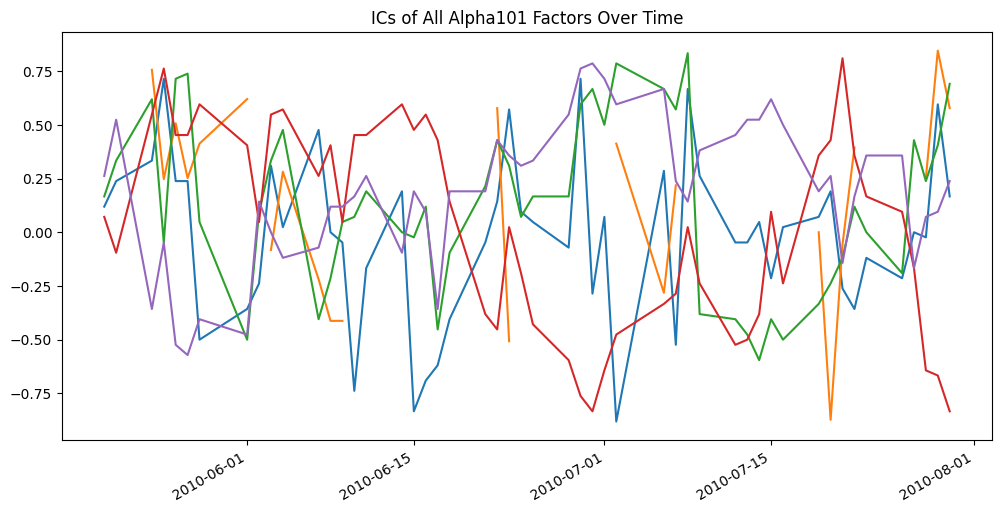

In [17]:
ic_df.iloc[1000:1050][ic_df.columns[random.sample(range(ic_df.shape[1]),5)]]\
    .plot(legend=False, 
          figsize=(12,6), 
          title='ICs of All Alpha101 Factors Over Time');

In [18]:
ic_df.columns = alpha_methods

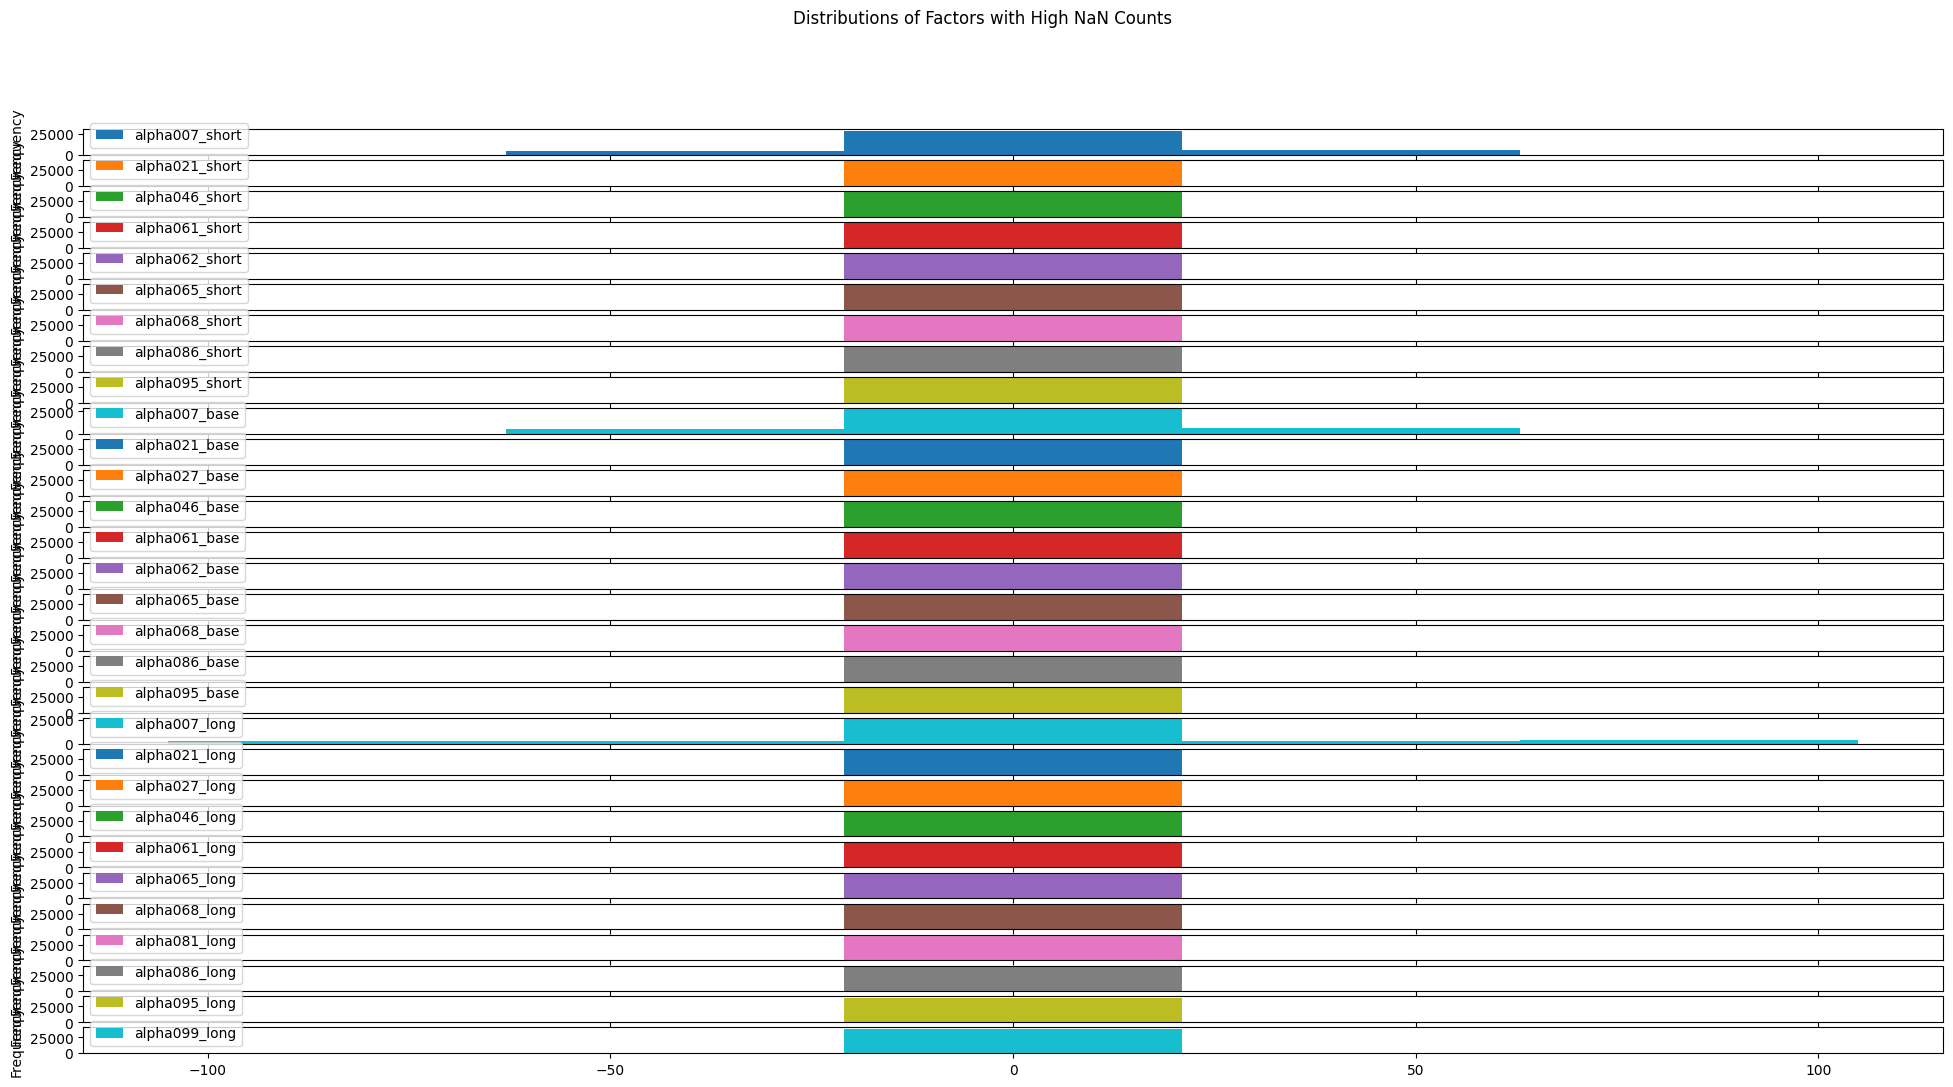

In [19]:
nan_id_columns = ic_df.columns[np.where(ic_df.isnull().sum() / len(ic_df) > 0.1)].to_list()
factor_table[nan_id_columns].plot(
    kind='hist', 
    bins=5, 
    figsize=(24, 12),  # You might want to increase figsize to accommodate more plots
    title='Distributions of Factors with High NaN Counts', 
    subplots=True,
);

#### interogate the alpha and find why there is so little signal

In [20]:
ic_df = ic_df[alpha_methods]
ic_df.shape

(4844, 246)

In [ ]:
# [factor for factor in factor_table.columns if factor in nan_id_columns]
# len([col for col in factor_table.columns if col.startswith('alpha')])

#### Part 3: Bias correction / neutralisation

Raw factors are not pure predictors, they often capture structural biases like:

- Industry effects (tech stocks move together)

- Size effects (small caps have higher volatility)

- Market-wide trends (momentum correlates with beta)

Neutralization ensures your factor’s correlation with forward returns isn’t just due to those broad effects.

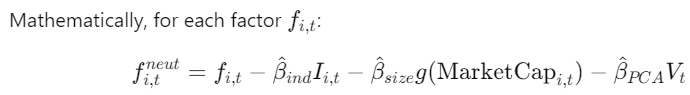

Stage 1. Identify systematic risk factors (via PCA)

Compute correlation matrix of factors.

Extract top K eigenvectors (principal components) representing “market-wide” common movements.

Optional: project factors orthogonally to remove those common components:
​
![image.png](attachment:ed279968-c4f5-4c21-b302-50b718d4710c.png)

Stage 2: Industry neutralisation

Regress each factor cross-sectionally on industry dummy variables:

![image.png](attachment:dde99fde-80d3-420e-8ff6-a12678a4b7fc.png)

Use robust regression (e.g., Huber, ridge) to avoid outlier distortion.

Stage 3: Size neutralisation (market cap bias)

Fit a log-linear model to remove linear and quadratic size effects

Stage 4: Adaptive neutralisation strength

In high-volatility regimes, use stronger neutralization (Du eq. 8):

![image.png](attachment:cc901f04-7497-40fb-9ca0-2b356a48c1cb.png)

Stage 5: Standardisation

After all neutralisation: Cross-sectionally z-score each factor (mean 0, std 1 per day).
This ensures no factor dominates due to scale.

In [24]:
# Neutralisation function
def neutralize_cross_sectional(table, factor_cols, industry_col='industry', cap_col='market_cap', variance_threshold=0.95, ridge_alpha=1.0):
    """
    table: long-format df with columns ['date','ticker', factor_cols..., industry_col, cap_col]
    factor_cols: list of factor column names to neutralize
    variance_threshold: the amount of variance to explain via PCA, e.g., 0.95 means 95% variance
    steps:
      1) for each date, create cross-sectional matrix F (n_stocks x n_factors)
      2) optional: PCA decomposition on F (correlation or covariance) and remove projection onto components that explain the desired variance threshold
      3) industry neutralization: regress each factor on industry dummies (ridge) and subtract predicted
      4) size neutralization: regress residual on log(market_cap) and (log(market_cap))^2
      5) z-score each factor cross-sectionally (per date)
    returns: table with neutralized factor columns appended as e.g. mom12_neut
    """
    out_rows = []
    dates = table['Date'].unique()
    
    for dt in tqdm(dates, desc='Neutralizing per date'):
        slice_df = table[table['Date'] == dt].copy()
        # Build factor matrix F (n_stocks x m_factors)
        F = slice_df[factor_cols].values

        # --- PCA removal based on variance threshold or no. of components ---
        if variance_threshold is not None and variance_threshold > 0:
            # Standardize the factors (columns mean=0, variance=1)
            scaler = StandardScaler(with_mean=True, with_std=True)
            Fc = scaler.fit_transform(F)
            
            # Perform PCA and get explained variance ratio
            pca = PCA()
            pca.fit(Fc)
            explained_variance_ratio = pca.explained_variance_ratio_

            ## Find the number of components that explain at least `variance_threshold` amount of variance
            # cumulative_variance = np.cumsum(explained_variance_ratio)
            # n_pcs_remove = np.argmax(cumulative_variance >= variance_threshold) + 1  # Get the number of PCs required
            ## Alternatively, we can just remove a fixed number of PCs, e.g., 1
            n_pcs_remove = 1 

            if n_pcs_remove > 0:
                pcs = pca.transform(Fc)  # Project data onto the principal components
                # Zero out the first n_pcs_remove components
                pcs_filtered = pcs.copy()
                pcs_filtered[:, :n_pcs_remove] = 0
                # Reconstruct using the remaining components
                F = pca.inverse_transform(pcs_filtered)
            else:
                F = Fc

        # Build industry dummies
        industries = pd.get_dummies(slice_df[industry_col].fillna('UNK'))
        
        # Regress each factor on industry dummies (ridge regression)
        X_ind = industries.values
        X_size = np.column_stack([np.log(slice_df[cap_col].values + 1e-9), np.log(slice_df[cap_col].values + 1e-9)**2])
        
        # Industry regression (Ridge to regularize)
        ridge = Ridge(alpha=ridge_alpha, fit_intercept=True)
        F_ind_neut = np.zeros_like(F)
        for j in range(F.shape[1]):
            y = F[:, j]
            # print(X_ind, y)
            ridge.fit(X_ind, y)
            y_hat = ridge.predict(X_ind)
            resid = y - y_hat
            F_ind_neut[:, j] = resid

        # Size neutralization: regress residual on log(cap) and squared
        F_size_neut = np.zeros_like(F_ind_neut)
        ridge2 = Ridge(alpha=ridge_alpha, fit_intercept=True)
        for j in range(F_ind_neut.shape[1]):
            y = F_ind_neut[:, j]
            # print(dt)
            # print(X_size)
            ridge2.fit(X_size, y)
            y_hat = ridge2.predict(X_size)
            resid = y - y_hat
            F_size_neut[:, j] = resid

        # Now z-score each column cross-sectionally
        F_z = (F_size_neut - np.nanmean(F_size_neut, axis=0)) / (np.nanstd(F_size_neut, axis=0) + 1e-9)

        # Attach results
        neut_cols = [f + '_neut' for f in factor_cols]
        neut_df = pd.DataFrame(F_z, columns=neut_cols, index=slice_df.index)
        slice_df = pd.concat([slice_df, neut_df], axis=1)
        
        out_rows.append(slice_df)

    out_df = pd.concat(out_rows, axis=0).sort_values(['Date','Ticker']).reset_index(drop=True)
    return out_df

In [ ]:
# check NA in factor_table. PCA computation fails if there are NaNs
na_cols = factor_table.columns[np.where(factor_table.isnull().sum() > 0)]
factor_table[na_cols].groupby('Date').size().value_counts()
# Get dates where all tickers have non-NA values for the na_cols
date_sizes = factor_table[na_cols].dropna(how='any').groupby('Date').size()
valid_dates = date_sizes[date_sizes >= len(tickers)].index
factor_table = factor_table.loc[valid_dates]

# Drop 1 year data for warm-up
factor_table = factor_table.sort_index()
dates_to_keep = factor_table.index.get_level_values(0).unique()[250:]
factor_table = factor_table[factor_table.index.get_level_values(0).isin(dates_to_keep)]

alpha_methods = [col for col in factor_table.columns if col.startswith('alpha')]

In [97]:
neut_df = neutralize_cross_sectional(
    table=factor_table.reset_index(),
    factor_cols=alpha_methods,
    industry_col='industry',
    cap_col='market_cap')
neut_df

Neutralizing per date: 100%|██████████| 4545/4545 [07:21<00:00, 10.31it/s]


,Date,Ticker,alpha001_short,alpha002_short,alpha003_short,alpha004_short,alpha005_short,alpha006_short,alpha007_short,alpha008_short,...,alpha085_long_neut,alpha086_long_neut,alpha088_long_neut,alpha092_long_neut,alpha094_long_neut,alpha095_long_neut,alpha096_long_neut,alpha098_long_neut,alpha099_long_neut,alpha101_long_neut
0,2007-07-05,XLB,0.790545,-0.781280,0.818639,-6.0,-0.027984,0.837110,-1.0,-0.779905,...,1.034419,0.0,1.310917,0.799001,1.421486,0.0,0.173201,-0.241645,0.974769,-1.370677
1,2007-07-05,XLE,0.471531,0.171887,0.520092,-6.0,-0.119329,0.547378,-1.0,-0.865555,...,0.340469,0.0,0.502560,-0.555548,0.284797,0.0,1.067609,-0.538859,0.703958,-0.047309
2,2007-07-05,XLF,0.476259,0.131981,0.721655,-6.0,-0.026157,0.726858,-1.0,-0.857525,...,0.639862,0.0,0.465171,-1.253534,-2.263449,0.0,0.826776,-1.225413,-1.433728,0.155030
3,2007-07-05,XLI,0.464748,-0.140246,0.163987,-6.0,-0.002970,0.168411,-1.0,-0.735845,...,-1.384962,0.0,-0.796961,0.621307,-0.461282,0.0,-1.309976,1.870743,1.545290,1.801684
4,2007-07-05,XLK,0.782939,-0.747195,0.185633,-7.0,-0.011215,0.249660,-36.0,-0.719992,...,0.780816,0.0,1.213960,0.808137,0.000020,0.0,-0.571898,0.579604,0.316972,0.081805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36355,2025-08-29,XLI,0.464748,0.973858,0.469019,-2.0,-0.119662,0.468490,16.0,-0.822112,...,-0.925183,0.0,0.499193,-0.260692,-0.710489,0.0,-1.836267,-0.364463,0.736337,-0.364135
36356,2025-08-29,XLK,0.451901,0.747081,0.188294,-4.0,-0.860746,0.134120,-1.0,-0.965823,...,0.001417,0.0,-0.832041,0.531229,-0.571850,0.0,-0.191464,0.792900,0.636267,0.559123
36357,2025-08-29,XLP,0.794553,-0.007848,-0.705953,-2.0,-0.004913,-0.700748,-1.0,-0.306568,...,-1.275788,0.0,-0.978706,-1.569870,1.641934,0.0,1.988351,-1.355408,-2.248704,0.800856
36358,2025-08-29,XLU,0.254985,0.041531,-0.139747,-1.0,-0.009528,-0.085541,40.0,-0.371011,...,0.996302,0.0,0.945380,-0.503325,1.408229,0.0,0.394883,-0.531576,0.141252,-1.603777


In [98]:
# Remove alpha columns with zero standard deviation
neut_df = neut_df.drop(columns=[col for col in neut_df.columns 
                        if col.startswith('alpha') and neut_df[col].std() == 0.0])

In [99]:
neut_df.to_csv('../data/factor_table_neut_v3.csv', index=False)

the effect of neutralisation is not very strong for majority of the factors

In [19]:
neut_df = pd.read_csv('../data/factor_table_neut_v3.csv')


In [20]:
neut_df[[col for col in neut_df.columns if col.endswith('_neut')]]

,alpha001_short_neut,alpha002_short_neut,alpha003_short_neut,alpha004_short_neut,alpha005_short_neut,alpha006_short_neut,alpha007_short_neut,alpha008_short_neut,alpha009_short_neut,alpha010_short_neut,...,alpha084_long_neut,alpha085_long_neut,alpha088_long_neut,alpha092_long_neut,alpha094_long_neut,alpha095_long_neut,alpha096_long_neut,alpha098_long_neut,alpha099_long_neut,alpha101_long_neut
0,1.411748,-1.625783,0.956192,-0.292917,0.170787,0.989613,-0.252426,0.859393,-0.880656,-0.259141,...,0.626400,1.034419,1.310917,0.799001,1.421486,0.0,0.173201,-0.241645,0.974769,-1.370677
1,0.076136,0.448342,-1.266076,0.501519,-0.670297,-1.207279,1.718232,0.647981,0.742597,0.086555,...,-0.965785,0.340469,0.502560,-0.555548,0.284797,0.0,1.067609,-0.538859,0.703958,-0.047309
2,-0.145510,1.120156,0.354751,-0.075911,0.281387,0.293382,0.401023,-0.606282,1.933181,2.109469,...,-1.473079,0.639862,0.465171,-1.253534,-2.263449,0.0,0.826776,-1.225413,-1.433728,0.155030
3,-0.278547,1.096118,-1.301561,-0.740698,0.980186,-1.167670,0.652805,0.869607,-0.491755,-0.550235,...,0.376665,-1.384962,-0.796961,0.621307,-0.461282,0.0,-1.309976,1.870743,1.545290,1.801684
4,1.624089,-0.612057,1.531884,-1.692570,1.705156,1.660887,-1.165081,0.583662,-0.905415,0.897549,...,0.950053,0.780816,1.213960,0.808137,0.000020,0.0,-0.571898,0.579604,0.316972,0.081805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36355,-0.444609,0.878849,0.912622,0.608348,0.859369,0.941884,0.358380,-0.563637,0.109793,0.084995,...,-0.046594,-0.925183,0.499193,-0.260692,-0.710489,0.0,-1.836267,-0.364463,0.736337,-0.364135
36356,1.120273,0.492268,0.527971,-1.133770,-1.242745,0.472179,-1.038771,-0.640142,0.934959,0.890814,...,0.180278,0.001417,-0.832041,0.531229,-0.571850,0.0,-0.191464,0.792900,0.636267,0.559123
36357,1.402842,-0.441724,-2.020687,1.306245,0.433151,-2.138125,-0.747058,1.004551,-0.719788,-0.769442,...,-0.388974,-1.275788,-0.978706,-1.569870,1.641934,0.0,1.988351,-1.355408,-2.248704,0.800856
36358,-1.952556,-0.953328,-0.543341,0.849532,1.666059,-0.428735,2.155666,0.993308,-1.791962,-1.556065,...,0.143196,0.996302,0.945380,-0.503325,1.408229,0.0,0.394883,-0.531576,0.141252,-1.603777


In [28]:
# Update factor table and alpha methods to only include neutralized factors
neut_cols = [col for col in neut_df.columns if col.endswith('_neut') or col in ['Date','Ticker','forward_return','market_cap','industry']]
neut_df = neut_df[neut_cols]
factor_table =  neut_df.set_index(['Date','Ticker']).sort_index()
alpha_methods = [col for col in factor_table.columns if col.startswith('alpha')]

# re-compute ICs for neutralized factors
ic_list = [compute_ic(factor_table, col, method='spearman') for col in tqdm(alpha_methods, desc='Computing ICs per neutralized factor')]
ic_df = pd.concat(ic_list, axis=1)
ic_df.columns = alpha_methods

ic_df.isnull().sum().sort_values().tail(10)

Computing ICs per neutralized factor: 100%|██████████| 239/239 [08:27<00:00,  2.12s/it]


alpha061_long_neut      683
alpha061_base_neut      727
alpha061_short_neut     732
alpha007_long_neut      744
alpha007_base_neut      745
alpha021_short_neut    1162
alpha021_base_neut     1248
alpha021_long_neut     1298
alpha095_base_neut     4543
alpha095_long_neut     4544
dtype: int64

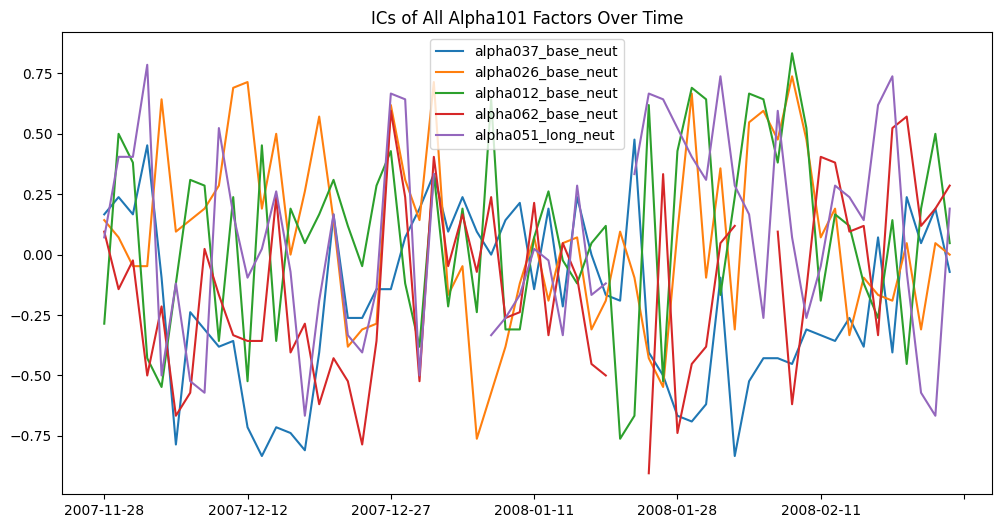

In [29]:
window = 60
start = random.randint(0, len(ic_df) - window)
sampled_rows = ic_df.iloc[start:start + window]
sampled_cols = random.sample(list(ic_df.columns), 5)

sampled_rows[sampled_cols].sort_index().plot(
    legend=True,
    figsize=(12, 6),
    title='ICs of All Alpha101 Factors Over Time'
);

Each IC series is a time series of daily correlations between the neutralized factor values and the forward returns over the 21-day horizon. It is a measure of, on each day, how well the factor's ranking predicted the cross-sectional return ranking over the next period 

Interpretation of mean ICs

| Mean IC    | Typical interpretation                  |
| ---------- | --------------------------------------- |
| > 0.05     | Very strong factor (rare)               |
| 0.02–0.05  | Good, likely tradable                   |
| 0.005–0.02 | Weak but possibly useful in combination |
| ~0         | Noise / no predictive power             |
| < 0        | Inverted signal (could short it)        |


In [30]:
def compute_ic_summary(ic_df):
    ic_summary = []
    for series in ic_df.columns:
        ic_summary.append({
            'Factor': series,
            'Mean IC': ic_df[series].mean(),
            'Std IC': ic_df[series].std(),
            'Mean to Std IC': ic_df[series].mean() / ic_df[series].std(),
            'Information ratio': ic_df[series].mean() / ic_df[series].std()
        })
    return pd.DataFrame(ic_summary)

ICs_summary = compute_ic_summary(ic_df)
display(ICs_summary)

,Factor,Mean IC,Std IC,Mean to Std IC,Information ratio
0,alpha001_short_neut,-0.006538,0.371771,-0.017586,-0.017586
1,alpha002_short_neut,0.006826,0.374808,0.018212,0.018212
2,alpha003_short_neut,0.000466,0.365999,0.001274,0.001274
3,alpha004_short_neut,0.001682,0.379015,0.004437,0.004437
4,alpha005_short_neut,-0.039311,0.388424,-0.101206,-0.101206
...,...,...,...,...,...
234,alpha095_long_neut,0.214286,NaN,NaN,NaN
235,alpha096_long_neut,0.006732,0.361803,0.018608,0.018608
236,alpha098_long_neut,-0.005857,0.375477,-0.015598,-0.015598
237,alpha099_long_neut,0.021064,0.371293,0.056732,0.056732


In [31]:
# Selection of top factors
ICs_summary.sort_values(by='Mean IC', ascending=False, key=abs).head(20)
# ICs_summary.sort_values(by='Mean IC', ascending=False).tail(20)

,Factor,Mean IC,Std IC,Mean to Std IC,Information ratio
154,alpha095_base_neut,-0.226190,0.117851,-1.919290,-1.919290
234,alpha095_long_neut,0.214286,NaN,NaN,NaN
176,alpha018_long_neut,-0.080090,0.377737,-0.212025,-0.212025
17,alpha018_short_neut,-0.075558,0.376149,-0.200871,-0.200871
96,alpha018_base_neut,-0.074950,0.376706,-0.198961,-0.198961
106,alpha028_base_neut,-0.062251,0.389802,-0.159698,-0.159698
186,alpha028_long_neut,-0.062209,0.383770,-0.162099,-0.162099
27,alpha028_short_neut,-0.061339,0.392685,-0.156204,-0.156204
36,alpha037_short_neut,-0.060312,0.392665,-0.153597,-0.153597
225,alpha077_long_neut,-0.060129,0.375409,-0.160169,-0.160169


# Pruning Factors

A multi-factor strategy’s goal isn’t just maximizing each factor’s standalone IC.

It’s about combining diverse, weakly correlated signals so the aggregate IC (or portfolio IR) is more stable.

*Key points:*

- Low correlation / orthogonal ICs → smoother combined performance.
- Factor rotation or pattern recognition (e.g., regime detection via ML or macro states) helps allocate weight dynamically.
- A few moderate-IC but complementary factors can outperform one large-IC factor that decays quickly.
- Think “ensemble learning” — robustness through diversification, not dominance.


> So yes, non-overlapping, compensating IC patterns across factors are often more valuable than one big IC

will remove correlated factors

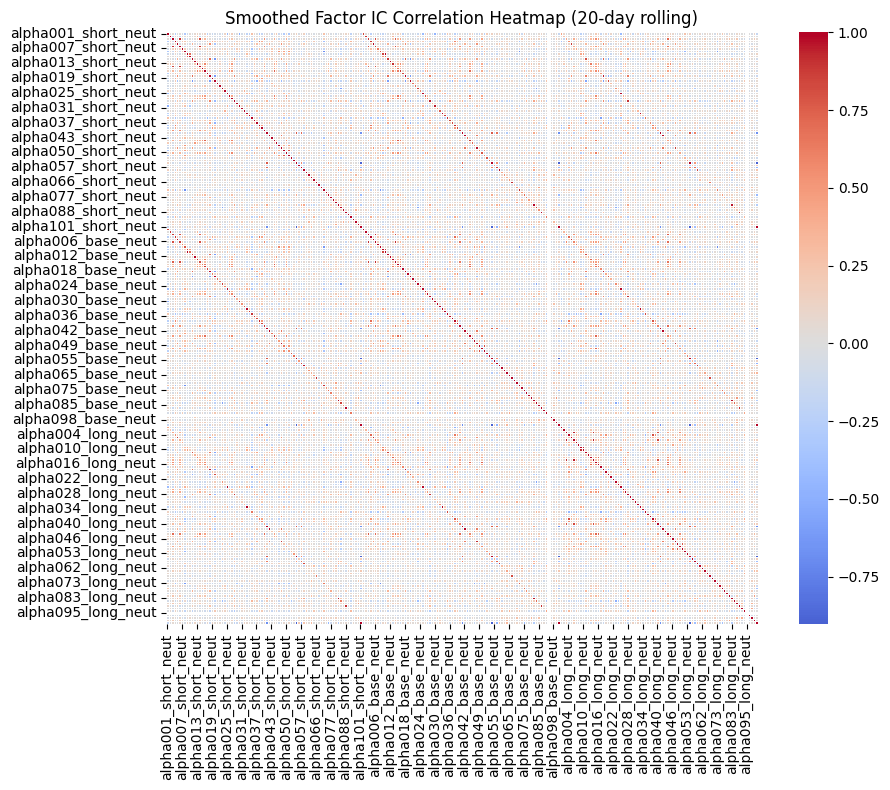

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Smooth ICs using rolling mean (e.g. 20-day)
ic_smooth = ic_df.rolling(20, min_periods=5).mean()

# Compute correlation across factors using smoothed ICs
corr = ic_smooth.corr()

# Optional: filter out weak correlations
# corr = corr[abs(corr) >= 0.1]

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr, 
    annot=False, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.5, square=True
)
plt.title("Smoothed Factor IC Correlation Heatmap (20-day rolling)")
plt.tight_layout()
plt.show()


In [140]:
def prune_redundant_factors(ic_df, corr_threshold=0.8, skip_factors=None, prune_bottom_pct=0.2):
    """
    Remove redundant factors that are highly correlated.
    Keeps the one with higher mean IC when |corr| > threshold.

    Parameters
    ----------
    ic_df : pd.DataFrame
        DataFrame of IC values (index = dates, columns = factors)
    corr_threshold : float
        Correlation threshold to treat factors as redundant

    Returns
    -------
    pd.DataFrame
        Filtered IC DataFrame with redundant factors removed
    """
    # Step 1: Prune bottom 20% by mean IC
    mean_ic = ic_df.mean()
    cutoff = mean_ic.quantile(prune_bottom_pct)
    
    # Keep factors above cutoff (or in skip_factors if provided)
    if skip_factors is not None:
        keep_mask = (mean_ic > cutoff) | (ic_df.columns.isin(skip_factors))
    else:
        keep_mask = mean_ic > cutoff
    
    ic_df = ic_df.loc[:, keep_mask]
    print(f"After IC pruning: {len(ic_df.columns)} factors remaining")
    
    # Step 2: Remove redundant correlated factors
    ic_smooth = ic_df.rolling(20, min_periods=5).mean()
    corr = ic_smooth.corr()
    mean_ic = ic_df.mean()
    to_drop = set()
    corr_columns = corr.columns.tolist()
    if skip_factors is not None:
        corr_columns = [col for col in corr.columns if col not in skip_factors]


    # Only consider upper triangle to avoid double-counting
    for i in range(len(corr_columns)):
        for j in range(i+1, len(corr_columns)):
            col_i = corr_columns[i]
            col_j = corr_columns[j]
            if abs(corr.loc[col_i, col_j]) > corr_threshold:
                # Drop factor with smaller mean IC
                drop = col_j if mean_ic[col_i] >= mean_ic[col_j] else col_i
                to_drop.add(drop)

    return ic_df.drop(columns=list(to_drop))


In [141]:
ic_df2 = prune_redundant_factors(ic_df, 
                                 corr_threshold=.5)
ic_df2.shape

After IC pruning: 191 factors remaining


(4545, 88)

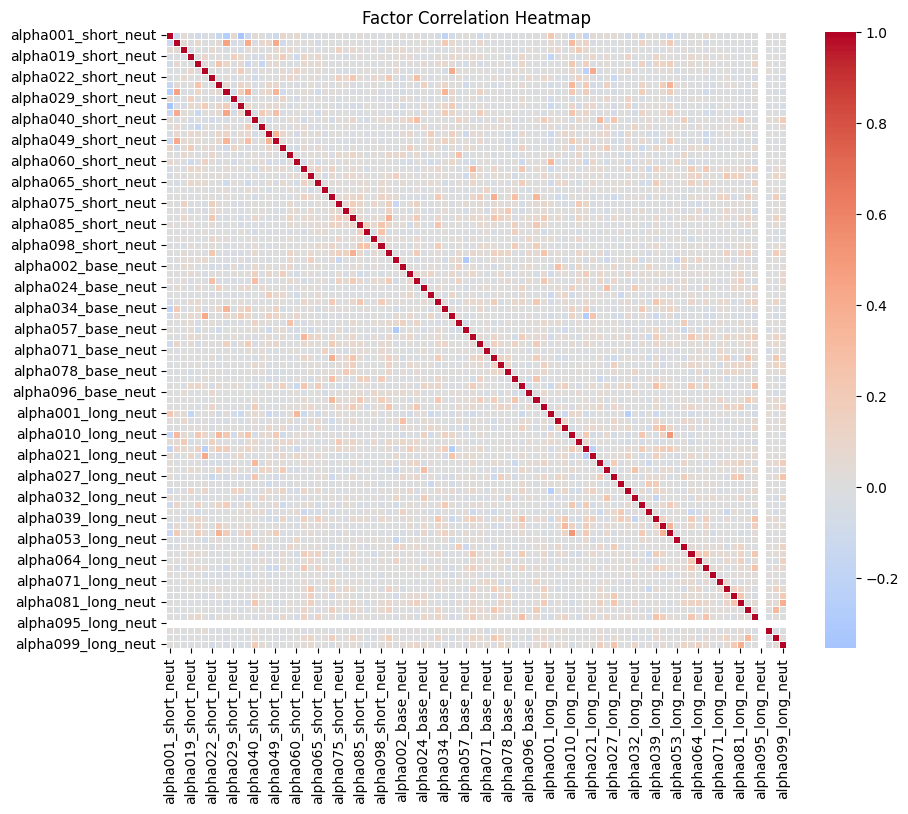

In [142]:
plt.figure(figsize=(10, 8))
sns.heatmap(ic_df2.corr(), annot=False, 
    cmap="coolwarm", center=0,
    linewidths=0.5,fmt=".2f")
plt.title("Factor Correlation Heatmap")
plt.show()

In [143]:
ic_df2.shape

(4545, 88)

In [144]:
# Save pruned factors to a text file
with open('../data/pruned_factors.txt', 'w') as f:
    f.write('\n'.join(ic_df2.columns.to_list()))

> get pruned factors df

In [145]:
pruned_factors = []
with open('../data/pruned_factors.txt', 'r') as f:
    pruned_factors = f.read().splitlines()

In [146]:
factor_table

market_cap          industry  forward_return  \
Date       Ticker                                                   
2007-07-05 XLB     8.933808e+08         Buildings       -0.076442   
           XLE     2.646477e+09            Energy       -0.075762   
           XLF     1.258812e+09        Financials       -0.125954   
           XLI     9.829422e+08       Industrials       -0.016332   
           XLK     1.810529e+09        Technology       -0.030593   
...                         ...               ...             ...   
2025-08-29 XLI     2.321119e+10       Industrials        0.028608   
           XLK     8.385155e+10        Technology        0.086306   
           XLP     1.570265e+10  Consumer Staples       -0.021602   
           XLU     2.090339e+10         Utilities        0.044705   
           XLV     3.381329e+10        Healthcare        0.016331   

                   alpha001_short_neut  alpha002_short_neut  \
Date       Ticker                                             
2007-07-05 XLB                1.411748            -1.625783   
           XLE                0.076136             0.448342   
           XLF               -0.145510             1.120156   
           XLI               -0.278547             1.096118   
           XLK                1.624089            -0.612057   
...                                ...                  ...   
2025-08-29 XLI               -0.444609             0.878849   
           XLK                1.120273             0.492268   
           XLP                1.402842            -0.441724   
           XLU               -1.952556            -0.953328   
           XLV                0.140798            -1.214752   

                   alpha003_short_neut  alpha004_short_neut  \
Date       Ticker                                             
2007-07-05 XLB                0.956192            -0.292917   
           XLE               -1.266076             0.501519   
           XLF                0.354751            -0.075911   
           XLI               -1.301561            -0.740698   
           XLK                1.531884            -1.692570   
...                                ...                  ...   
2025-08-29 XLI                0.912622             0.608348   
           XLK                0.527971            -1.133770   
           XLP               -2.020687             1.306245   
           XLU               -0.543341             0.849532   
           XLV               -0.888432             0.947897   

                   alpha005_short_neut  alpha006_short_neut  \
Date       Ticker                                             
2007-07-05 XLB                0.170787             0.989613   
           XLE               -0.670297            -1.207279   
           XLF                0.281387             0.293382   
           XLI                0.980186            -1.167670   
           XLK                1.705156             1.660887   
...                                ...                  ...   
2025-08-29 XLI                0.859369             0.941884   
           XLK               -1.242745             0.472179   
           XLP                0.433151            -2.138125   
           XLU                1.666059            -0.428735   
           XLV                0.482935            -0.747023   

                   alpha007_short_neut  ...  alpha084_long_neut  \
Date       Ticker                       ...                       
2007-07-05 XLB               -0.252426  ...            0.626400   
           XLE                1.718232  ...           -0.965785   
           XLF                0.401023  ...           -1.473079   
           XLI                0.652805  ...            0.376665   
           XLK               -1.165081  ...            0.950053   
...                                ...  ...                 ...   
2025-08-29 XLI                0.358380  ...           -0.046594   
           XLK               -1.038771  ...            0.180

In [147]:
'alpha068_short_neut' in pruned_factors

False

In [148]:
factor_table.shape

(36360, 242)

# Fit models on alphas

## Create 'Naive' baseline with equal weighted for all factors

In [149]:
## might be useful to get base line

# build composite alpha function  builds a composite alpha column (the final signal) from the ICs of each factor combined with its weightage
# Weighting is meant to combine factors so that more predictive factors contribute more to the composite alpha
# The coding here uses absolute IC weighting and has parameterisation for equal weighting
def build_composite_alpha(table_neut, factor_cols, ic_summary=None, weighted=False):
    df = table_neut.copy()
    
    # Define weights
    if weighted and ic_summary is not None:
        weights = np.array([ic_summary.get(f, 0.0) for f in factor_cols])
        weights /= np.sum(np.abs(weights)) + 1e-12
    else:
        weights = np.ones(len(factor_cols)) / len(factor_cols)
    
    # Weighted combination (row-wise dot product)
    df['composite_alpha'] = df[factor_cols].fillna(0).dot(weights)
    
    # Z-score within each date
    df['composite_alpha'] = (df.groupby('Date')['composite_alpha'].transform(lambda x: (x - x.mean()) / (x.std() + 1e-9)))
    return df

In [150]:
baseline_df =\
build_composite_alpha(factor_table, pruned_factors, 
                      ic_summary=None,
                      weighted=False)

In [151]:
baseline_df

market_cap          industry  forward_return  \
Date       Ticker                                                   
2007-07-05 XLB     8.933808e+08         Buildings       -0.076442   
           XLE     2.646477e+09            Energy       -0.075762   
           XLF     1.258812e+09        Financials       -0.125954   
           XLI     9.829422e+08       Industrials       -0.016332   
           XLK     1.810529e+09        Technology       -0.030593   
...                         ...               ...             ...   
2025-08-29 XLI     2.321119e+10       Industrials        0.028608   
           XLK     8.385155e+10        Technology        0.086306   
           XLP     1.570265e+10  Consumer Staples       -0.021602   
           XLU     2.090339e+10         Utilities        0.044705   
           XLV     3.381329e+10        Healthcare        0.016331   

                   alpha001_short_neut  alpha002_short_neut  \
Date       Ticker                                             
2007-07-05 XLB                1.411748            -1.625783   
           XLE                0.076136             0.448342   
           XLF               -0.145510             1.120156   
           XLI               -0.278547             1.096118   
           XLK                1.624089            -0.612057   
...                                ...                  ...   
2025-08-29 XLI               -0.444609             0.878849   
           XLK                1.120273             0.492268   
           XLP                1.402842            -0.441724   
           XLU               -1.952556            -0.953328   
           XLV                0.140798            -1.214752   

                   alpha003_short_neut  alpha004_short_neut  \
Date       Ticker                                             
2007-07-05 XLB                0.956192            -0.292917   
           XLE               -1.266076             0.501519   
           XLF                0.354751            -0.075911   
           XLI               -1.301561            -0.740698   
           XLK                1.531884            -1.692570   
...                                ...                  ...   
2025-08-29 XLI                0.912622             0.608348   
           XLK                0.527971            -1.133770   
           XLP               -2.020687             1.306245   
           XLU               -0.543341             0.849532   
           XLV               -0.888432             0.947897   

                   alpha005_short_neut  alpha006_short_neut  \
Date       Ticker                                             
2007-07-05 XLB                0.170787             0.989613   
           XLE               -0.670297            -1.207279   
           XLF                0.281387             0.293382   
           XLI                0.980186            -1.167670   
           XLK                1.705156             1.660887   
...                                ...                  ...   
2025-08-29 XLI                0.859369             0.941884   
           XLK               -1.242745             0.472179   
           XLP                0.433151            -2.138125   
           XLU                1.666059            -0.428735   
           XLV                0.482935            -0.747023   

                   alpha007_short_neut  ...  alpha085_long_neut  \
Date       Ticker                       ...                       
2007-07-05 XLB               -0.252426  ...            1.034419   
           XLE                1.718232  ...            0.340469   
           XLF                0.401023  ...            0.639862   
           XLI                0.652805  ...           -1.384962   
           XLK               -1.165081  ...            0.780816   
...                                ...  ...                 ...   
2025-08-29 XLI                0.358380  ...           -0.925183   
           XLK               -1.038771  ...            0.001

In [152]:
baseline_df.reset_index().pivot(index='Date', columns='Ticker', values='composite_alpha')

Ticker,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV
Date,,,,,,,,
2007-07-05,-0.517557,-0.920176,0.069630,-0.015809,-0.899547,0.330554,2.212362,-0.259456
2007-07-06,-0.164579,-0.901062,-0.054671,0.486431,-0.693325,-0.723477,2.211644,-0.160961
2007-07-09,0.673847,-0.393371,-1.226808,1.219773,0.419629,-1.273854,1.136216,-0.555433
2007-07-10,1.310438,-0.020125,-0.990596,0.222091,0.739876,-0.515167,0.883779,-1.630296
2007-07-11,0.239261,-0.651627,-0.748626,1.162383,1.012534,-0.737723,1.086431,-1.362633
...,...,...,...,...,...,...,...,...
2025-08-25,0.031942,-0.248631,-0.042677,-0.331607,-0.418389,0.546840,-1.535704,1.998226
2025-08-26,0.196045,-1.310214,0.284943,-0.516990,-0.237878,0.634723,-0.937107,1.886479
2025-08-27,0.727113,-2.161248,0.120046,0.229972,0.619503,-0.764689,0.681335,0.547968


In [153]:
# baseline_df
baseline_df["pct_rank"] = baseline_df.groupby(level="Date")["composite_alpha"].rank(pct=True).head(20)
# Buy if top half, Sell if bottom half
baseline_df["signal"] = (baseline_df["pct_rank"] > 0.5).astype(int) * 2 - 1
# gives 1 for buy, -1 for sell

# add forward returns
baseline_df['strategy_return'] = baseline_df['signal'] * baseline_df['forward_return']

In [154]:
baseline_df['gross_return'] = baseline_df['strategy_return'] +1

strategy_returns = baseline_df.groupby(["Date", "Ticker"])["gross_return"].mean() ** (1 / HORIZON)

In [155]:
naive_daily_return = baseline_df.groupby('Date')['gross_return'].mean()

## Create Long only

In [156]:
baseline_df['passive_gross_return'] = baseline_df['forward_return'] + 1

In [157]:
longonly_returns = baseline_df.groupby(level=['Date'])['passive_gross_return'].mean()


In [158]:
longonly_daily_return = (longonly_returns ** (1 / HORIZON))

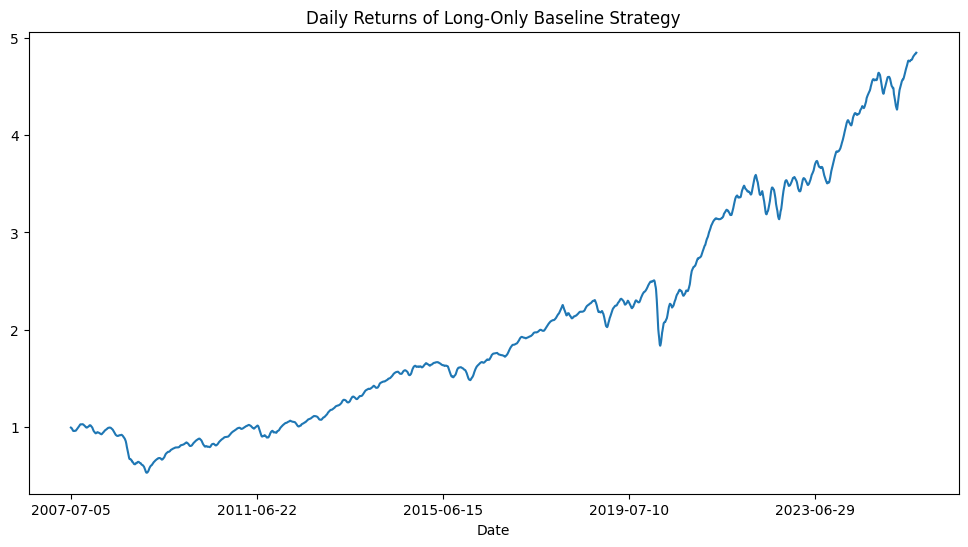

In [159]:
longonly_daily_return.cumprod().plot(figsize=(12,6), title='Daily Returns of Long-Only Baseline Strategy');

In [160]:
baseline_df = baseline_df.reset_index()

## Create Xgboost model

{'colsample_bytree': 0.7, 'learning_rate': 0.003, 'max_depth': 3, 'n_estimators': 1000, 'subsample': 0.7}

### Random search
Best parameters found:
{'subsample': 0.8, 'n_estimators': 1500, 'max_depth': 3, 'learning_rate': 0.003, 'colsample_bytree': 0.8}
Best cross-validation score: 0.0029

- v2 more alphas 7.5 mins training
{'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.003}

- v3 extended estimators 74 min training
Best parameters found:
{'n_estimators': 1000, 'max_depth': 5, 'learning_rate': 0.003}
Best cross-validation score: 0.0035

In [161]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

In [195]:
def get_long_short_signals(df, frac=0.25):
    """
    Generate dollar-neutral long/short signals from predicted scores.
    
    Parameters
    ----------
    lgb_df : DataFrame
        Columns = ['Date', 'Ticker', 'pred']
    frac : float
        Fraction of universe to long and short (e.g., 0.25 = top/bottom 25%)
    total_cap : float
        Total notional exposure (long + short)
    
    Returns
    -------
    signal_df : DataFrame
        Index = Date, Columns = Ticker, values = scaled signals
    """
    pred_pivot = df.pivot(index='Date', columns='Ticker', values='pred')
    n = pred_pivot.shape[1]

    num_longs = int(np.floor(frac * n))
    num_shorts = int(np.floor(frac * n))

    # argsort twice to get ranks fast
    ranks = pred_pivot.to_numpy().argsort(axis=1).argsort(axis=1)
    signals = np.zeros_like(ranks, dtype=float)

    # Mark longs and shorts by rank index
    signals[ranks >= n - num_longs] = 1
    signals[ranks < num_shorts] = -1

    # Scale for dollar neutrality
    scale = n / (num_longs+ num_shorts)
    signals *= scale

    signal_df = pd.DataFrame(signals, index=pred_pivot.index, columns=pred_pivot.columns).stack().values
    return signal_df

# lgb_df['signal'] = get_long_short_signals(lgb_df, frac=0.25)

In [163]:
xg_df = baseline_df.drop(columns=['composite_alpha', 'pct_rank', 'signal', 'strategy_return'])\
                .copy().sort_index()
X = factor_table.reset_index()[pruned_factors]
y = factor_table.reset_index()['forward_return']

In [164]:
# Get unique dates
dates = baseline_df['Date'].unique()
n_dates = len(dates)
n_tickers = len(tickers)

# 80/10/10 split indices
train_end = int(0.8 * n_dates) * n_tickers
val_end = int(0.9 * n_dates) * n_tickers

# Mask by date
X_train = X[:train_end]
X_val = X[train_end:val_end]
X_test = X[val_end:]

y_train = y.loc[X_train.index]
y_val = y.loc[X_val.index]
y_test = y.loc[X_test.index]

print(X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape)


(29088, 88) (3632, 88) (3640, 88) (29088,) (3632,) (3640,)


In [ ]:
print("=" * 60)
print("PHASE 1: Initial Hyperparameter Tuning or Loading Saved Parameters")
print("=" * 60)

if os.path.exists('../data/best_xgb_params.json'):
    with open('../data/best_xgb_params.json', 'r') as f:
        loaded_params = json.load(f)
    best_params = loaded_params
else:
    param_distributions = {
        'n_estimators': [1000, 2000, 2100],
        'learning_rate': [0.0003, 0.0015, 0.003],
        'max_depth': [5, 12]
        # 'subsample': [0.7, 0.8, 0.9],
        # 'colsample_bytree': [0.7, 0.8, 0.9],
    }
    # Initialize base model
    base_model = xgb.XGBRegressor(random_state=RANDOM_SEED, objective='reg:squarederror')
    # Set up RandomizedSearchCV
    random_search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        n_iter=20,
        cv=3,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=2,
        random_state=RANDOM_SEED
    )
    # Fit on full training set
    print("Starting randomized search on training set...")
    random_search.fit(X_train, y_train)

    print("\nBest parameters found:")
    print(random_search.best_params_)
    print(f"Best cross-validation score: {-random_search.best_score_:.4f}")

    # Get best parameters
    best_params = random_search.best_params_

    # Save to JSON  
    with open('../data/best_xgb_params.json', 'w') as f:
        json.dump(best_params, f, indent=4)

PHASE 1: Initial Hyperparameter Tuning or Loading Saved Parameters
Starting randomized search on training set...
Fitting 3 folds for each of 18 candidates, totalling 54 fits


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_search.py:318: UserWarning: The total space of parameters 18 is smaller than n_iter=20. Running 18 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV] END learning_rate=0.0003, max_depth=5, n_estimators=1000; total time=  17.8s
[CV] END learning_rate=0.0003, max_depth=5, n_estimators=1000; total time=  18.0s
[CV] END learning_rate=0.0003, max_depth=5, n_estimators=1000; total time=  18.1s


In [ ]:
# ============================================
# PHASE 2: Walk-Forward with Periodic Retraining (Rolling Window + Warm Start)
# ============================================
retrain_frequency = HORIZON * len(tickers) # Retrain every HORIZON samples e.g. 1 month
window_size = HORIZON * len(tickers)  # Add last 1 month data rows for training
predictions = []
current_model = None
initial_train_size = len(X_train)

print(f"\nRetraining every {retrain_frequency} samples")
print(f"Using rolling window of {window_size} samples")

for i in tqdm(range(initial_train_size, len(X))):
    # Retrain when needed
    if (i - initial_train_size) % retrain_frequency == 0 or current_model is None:
        # Get the latest window_size rows for training
        start_idx = max(0, i - window_size)
        X_train_wf = X.iloc[:i].copy()
        y_train_wf = y.iloc[:i].copy()

        if current_model is None:
            # First iteration: train from scratch
            current_model = xgb.XGBRegressor(
                **best_params, 
                random_state=RANDOM_SEED, 
                objective='reg:squarederror'
            )
            current_model.fit(X_train_wf, y_train_wf)
            print(f"Initial model trained at sample {i - initial_train_size + 1} with {len(X_train_wf)} rows")
        else:
            # Subsequent iterations: warm start from previous model
            current_model.fit(
                X_train_wf, 
                y_train_wf,
                xgb_model=current_model.get_booster()  # Warm start from previous model
            )
            print(f"Model updated (warm start) at sample {i - initial_train_size + 1} with {len(X_train_wf)} rows")
    
    # Predict using current model
    X_test_wf = X.iloc[i:i+1].copy()
    pred = current_model.predict(X_test_wf)[0]
    predictions.append(pred)
    
    # Progress update
    if (i - initial_train_size + 1) % 250 == 0:
        print(f"Processed {i - initial_train_size + 1}/{len(X) - initial_train_size} predictions")

print(f"\nCompleted {len(predictions)} walk-forward predictions")

# ============================================
# COMBINE PREDICTIONS
# ============================================
# Initial model predictions on training set
model_initial = xgb.XGBRegressor(**best_params, random_state=RANDOM_SEED, objective='reg:squarederror')
model_initial.fit(X_train, y_train)
train_predictions = model_initial.predict(X_train)

# Split walk-forward predictions into val and test
val_predictions = predictions[:len(X_val)]
test_predictions = predictions[len(X_val):]

# Combine all predictions
xg_df["pred"] = np.nan
xg_df.loc[X_train.index, "pred"] = train_predictions
xg_df.loc[X_val.index, "pred"] = val_predictions
xg_df.loc[X_test.index, "pred"] = test_predictions


Retraining every 160 samples
Using rolling window of 160 samples


  0%|          | 17/7272 [00:04<25:32,  4.74it/s] 

Initial model trained at sample 1 with 29088 rows


  3%|▎         | 185/7272 [00:10<08:14, 14.34it/s] 

Model updated (warm start) at sample 161 with 29248 rows


...

Model updated (warm start) at sample 7201 with 36288 rows


100%|█████████▉| 7265/7272 [06:18<00:00, 24.47it/s]

Processed 7250/7272 predictions


100%|██████████| 7272/7272 [06:18<00:00, 19.21it/s]



Completed 7272 walk-forward predictions


In [ ]:
# Combine all predictions
# xg_df["pred"] = np.nan
# xg_df.loc[X_train.index, "pred"] = train_predictions
# xg_df.loc[X_val.index, "pred"] = val_predictions
# xg_df.loc[X_test.index, "pred"] = test_predictions

In [ ]:
xg_df

,Date,Ticker,market_cap,industry,forward_return,alpha001_short_neut,alpha002_short_neut,alpha003_short_neut,alpha004_short_neut,alpha005_short_neut,...,alpha095_long_neut,alpha096_long_neut,alpha098_long_neut,alpha099_long_neut,alpha101_long_neut,gross_return,passive_gross_return,pred,signal,strategy_return
0,2007-07-05,XLB,8.933808e+08,Buildings,-0.076442,1.411748,-1.625783,0.956192,-0.292917,0.170787,...,0.0,0.173201,-0.241645,0.974769,-1.370677,NaN,0.923558,0.009776,None,NaN
1,2007-07-05,XLE,2.646477e+09,Energy,-0.075762,0.076136,0.448342,-1.266076,0.501519,-0.670297,...,0.0,1.067609,-0.538859,0.703958,-0.047309,NaN,0.924238,0.005382,None,NaN
2,2007-07-05,XLF,1.258812e+09,Financials,-0.125954,-0.145510,1.120156,0.354751,-0.075911,0.281387,...,0.0,0.826776,-1.225413,-1.433728,0.155030,NaN,0.874046,-0.000668,None,NaN
3,2007-07-05,XLI,9.829422e+08,Industrials,-0.016332,-0.278547,1.096118,-1.301561,-0.740698,0.980186,...,0.0,-1.309976,1.870743,1.545290,1.801684,NaN,0.983668,0.012345,None,NaN
4,2007-07-05,XLK,1.810529e+09,Technology,-0.030593,1.624089,-0.612057,1.531884,-1.692570,1.705156,...,0.0,-0.571898,0.579604,0.316972,0.081805,NaN,0.969407,0.011012,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36355,2025-08-29,XLI,2.321119e+10,Industrials,0.028608,-0.444609,0.878849,0.912622,0.608348,0.859369,...,0.0,-1.836267,-0.364463,0.736337,-0.364135,NaN,1.028608,0.002105,None,NaN
36356,2025-08-29,XLK,8.385155e+10,Technology,0.086306,1.120273,0.492268,0.527971,-1.133770,-1.242745,...,0.0,-0.191464,0.792900,0.636267,0.559123,NaN,1.086306,-0.009199,None,NaN
36357,2025-08-29,XLP,1.570265e+10,Consumer Staples,-0.021602,1.402842,-0.441724,-2.020687,1.306245,0.433151,...,0.0,1.988351,-1.355408,-2.248704,0.800856,NaN,0.978398,-0.008477,None,NaN
36358,2025-08-29,XLU,2.090339e+10,Utilities,0.044705,-1.952556,-0.953328,-0.543341,0.849532,1.666059,...,0.0,0.394883,-0.531576,0.141252,-1.603777,NaN,1.044705,0.002227,None,NaN


In [ ]:
# ============================================
# GENERATE SIGNALS & RETURNS
# ============================================
# Rank predictions per date → long/short
xg_df["signal"] = get_long_short_signals(xg_df, frac=1/8)

xg_df['strategy_return'] = xg_df['signal'] * xg_df['forward_return']

xg_df['gross_return'] = xg_df['strategy_return'] + 1


print(f"\n{'='*60}")
print("Performance Metrics")
print(f"{'='*60}")
print(f"Train period sharpe: {xg_df.loc[X_train.index, 'strategy_return'].mean() / xg_df.loc[X_train.index, 'strategy_return'].std() * np.sqrt(252):.3f}")
print(f"Test period sharpe: {xg_df.loc[X_test.index, 'strategy_return'].mean() / xg_df.loc[X_test.index, 'strategy_return'].std() * np.sqrt(252):.3f}")


Performance Metrics
Train period sharpe: 1.973
Test period sharpe: -0.244


In [ ]:
## After RandomizedSearchCV
# best_params = random_search.best_params_

## Save to JSON  
# with open('../data/best_xgb_params.json', 'w') as f:
#     json.dump(best_params, f, indent=4)

## Create LGB Model

Best parameters found:
{'subsample': 0.9, 'num_leaves': 50, 'n_estimators': 2000, 'min_child_samples': 50, 'max_depth': 3, 'learning_rate': 0.003, 'colsample_bytree': 0.7}
### Random search
Best parameters: {'subsample': 1.0, 'reg_alpha': 1.0, 'num_leaves': 31, 'n_estimators': 800, 'min_child_samples': 50, 'max_depth': 1, 'learning_rate': 0.001, 'colsample_bytree': 0.7}

- v2 more alphas
Best parameters: {'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alpha': 0.01, 'num_leaves': 15, 'n_estimators': 50, 'min_child_samples': 5, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.9}
Best CV score: 0.003466

- v3 more trees
Best parameters: {'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alpha': 0.01, 'num_leaves': 15, 'n_estimators': 500, 'min_child_samples': 5, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.9}
Best CV score: 0.003494



In [ ]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split

In [ ]:
lgb_df = baseline_df.drop(columns=['composite_alpha', 'pct_rank', 'signal', 'strategy_return']).copy()


In [ ]:
print("=" * 60)
print("PHASE 1: Initial Hyperparameter Tuning or Loading Saved Parameters")
print("=" * 60)

if os.path.exists('../data/best_lgb_params.json'):
    with open('../data/best_lgb_params.json', 'r') as f:
        loaded_params = json.load(f)
    best_params = loaded_params
else:
    param_distributions = {
    'n_estimators': [500, 2500, 3000],
    'learning_rate': [.0001, .005, 0.01],
    'max_depth': [7, 10, 12],  # -1 means no limit
    'num_leaves': [15, 31, 63, 127],
    'min_child_samples': [5, 10, 20, 30],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0.01, 0.1, 1.0],  # L1 regularization
    'reg_lambda': [0, 0.01, 0.1, 1.0],  # L2 regularization
    }

    # Base model
    base_model = lgb.LGBMRegressor(random_state=RANDOM_SEED,objective='regression',metric='rmse',verbosity=-1, force_col_wise=True  # Faster for wide datasets
    )
    # Randomized search
    print("Starting LightGBM hyperparameter tuning...")
    random_search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        n_iter=20,
        cv=3,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=2,
        random_state=RANDOM_SEED
    )
    random_search.fit(X_train, y_train)

    best_params = random_search.best_params_
    print(f"\nBest parameters: {best_params}")
    print(f"Best CV score: {-random_search.best_score_:.6f}")
    with open(f'../data/best_lgb_params.json', 'w') as f:
        json.dump(best_params, f, indent=4)

PHASE 1: Initial Hyperparameter Tuning or Loading Saved Parameters
Starting LightGBM hyperparameter tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=0.9, learning_rate=0.05, max_depth=10, min_child_samples=30, n_estimators=500, num_leaves=15, reg_alpha=0.1, reg_lambda=1.0, subsample=0.9; total time=   8.6s
[CV] END colsample_bytree=0.9, learning_rate=0.05, max_depth=10, min_child_samples=30, n_estimators=500, num_leaves=15, reg_alpha=0.1, reg_lambda=1.0, subsample=0.9; total time=   8.9s
[CV] END colsample_bytree=0.9, learning_rate=0.05, max_depth=10, min_child_samples=30, n_estimators=500, num_leaves=15, reg_alpha=0.1, reg_lambda=1.0, subsample=0.9; total time=   9.1s
[CV] END colsample_bytree=0.9, learning_rate=0.01, max_depth=7, min_child_samples=5, n_estimators=500, num_leaves=15, reg_alpha=0.01, reg_lambda=0.1, subsample=1.0; total time=   8.9s
[CV] END colsample_bytree=0.9, learning_rate=0.01, max_depth=7, min_child_samples=5, n_est

In [ ]:
# ============================================
# PHASE 2: Walk-Forward with Periodic Retraining (Expanding Window)
# ============================================
retrain_frequency = HORIZON * len(tickers)  # Retrain every HORIZON samples
predictions = []
current_model = None
initial_train_size = len(X_train)

print(f"\nRetraining every {retrain_frequency} samples")
print(f"Using expanding window")

for i in tqdm(range(initial_train_size, len(X))):
    # Retrain when needed
    if (i - initial_train_size) % retrain_frequency == 0 or current_model is None:
        # Expanding window: train from start to current position
        X_train_wf = X.iloc[:i].copy()
        y_train_wf = y.iloc[:i].copy()
        
        if current_model is None:
            # First iteration: train from scratch
            current_model = lgb.LGBMRegressor(
                **best_params,
                random_state=RANDOM_SEED,
                objective='regression',
                metric='rmse',
                verbosity=-1,
                force_col_wise=True
            )
            current_model.fit(X_train_wf, y_train_wf)
            print(f"\nInitial model trained at sample {i - initial_train_size + 1} with {len(X_train_wf)} rows")
        else:
            # Subsequent iterations: continue training from previous model
            # LightGBM's warm start: init_model parameter
            current_model.fit(
                X_train_wf,
                y_train_wf,
                init_model=current_model  # Warm start from previous model
            )
            print(f"\nModel updated (warm start) at sample {i - initial_train_size + 1} with {len(X_train_wf)} rows")
    
    # Predict using current model
    X_test_wf = X.iloc[i:i+1].copy()
    pred = current_model.predict(X_test_wf)[0]
    predictions.append(pred)
    
    # Progress update
    if (i - initial_train_size + 1) % 250 == 0:
        print(f"Processed {i - initial_train_size + 1}/{len(X) - initial_train_size} predictions")

print(f"\nCompleted {len(predictions)} walk-forward predictions")


Retraining every 160 samples
Using expanding window


  0%|          | 1/7272 [00:02<4:22:09,  2.16s/it]


Initial model trained at sample 1 with 29088 rows


  2%|▏         | 161/7272 [00:04<02:48, 42.17it/s]


Model updated (warm start) at sample 161 with 29248 rows
Processed 250/7272 predictions


...


Model updated (warm start) at sample 6881 with 35968 rows
Processed 7000/7272 predictions


 98%|█████████▊| 7127/7272 [04:16<00:08, 17.78it/s]


Model updated (warm start) at sample 7041 with 36128 rows


100%|██████████| 7272/7272 [04:27<00:00, 27.16it/s]


Model updated (warm start) at sample 7201 with 36288 rows
Processed 7250/7272 predictions

Completed 7272 walk-forward predictions


In [ ]:
# ============================================
# COMBINE PREDICTIONS
# ============================================
# Initial model predictions on training set
model_initial = lgb.LGBMRegressor(**best_params, random_state=RANDOM_SEED,objective='regression', metric='rmse')
model_initial.fit(X_train, y_train)
train_predictions = model_initial.predict(X_train)

# Split walk-forward predictions into val and test
val_predictions = predictions[:len(X_val)]
test_predictions = predictions[len(X_val):]

# Combine all predictions
lgb_df["pred"] = np.nan
lgb_df.loc[X_train.index, "pred"] = train_predictions
lgb_df.loc[X_val.index, "pred"] = val_predictions
lgb_df.loc[X_test.index, "pred"] = test_predictions


In [ ]:
# ============================================
# GENERATE SIGNALS & RETURNS
# ============================================
# Rank predictions per date → long/short
lgb_df["signal"] = get_long_short_signals(lgb_df, frac=1/2)

lgb_df['strategy_return'] = lgb_df['signal'] * lgb_df['forward_return']
lgb_df['gross_return'] = lgb_df['strategy_return'] + 1


print(f"\n{'='*60}")
print("Performance Metrics")
print(f"{'='*60}")
print(f"Train period sharpe: {lgb_df.loc[X_train.index, 'strategy_return'].mean() / lgb_df.loc[X_train.index, 'strategy_return'].std() * np.sqrt(252):.3f}")
print(f"Test period sharpe: {lgb_df.loc[X_test.index, 'strategy_return'].mean() / lgb_df.loc[X_test.index, 'strategy_return'].std() * np.sqrt(252):.3f}")


Performance Metrics
Train period sharpe: 1.898
Test period sharpe: -0.090


# Evaluation

## Naive cum returns

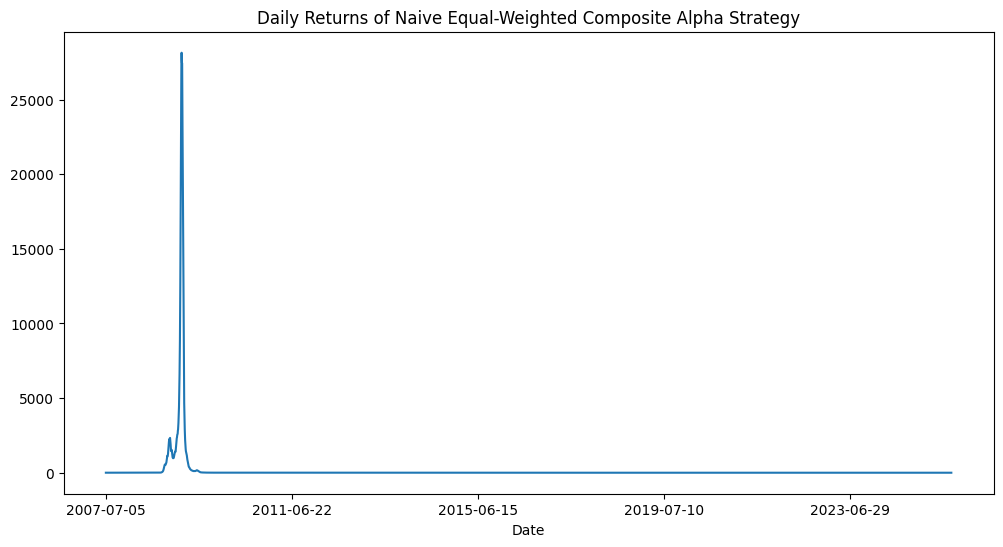

In [ ]:
naive_daily_return.cumprod().plot(figsize=(12,6), title='Daily Returns of Naive Equal-Weighted Composite Alpha Strategy');

## Long only returns

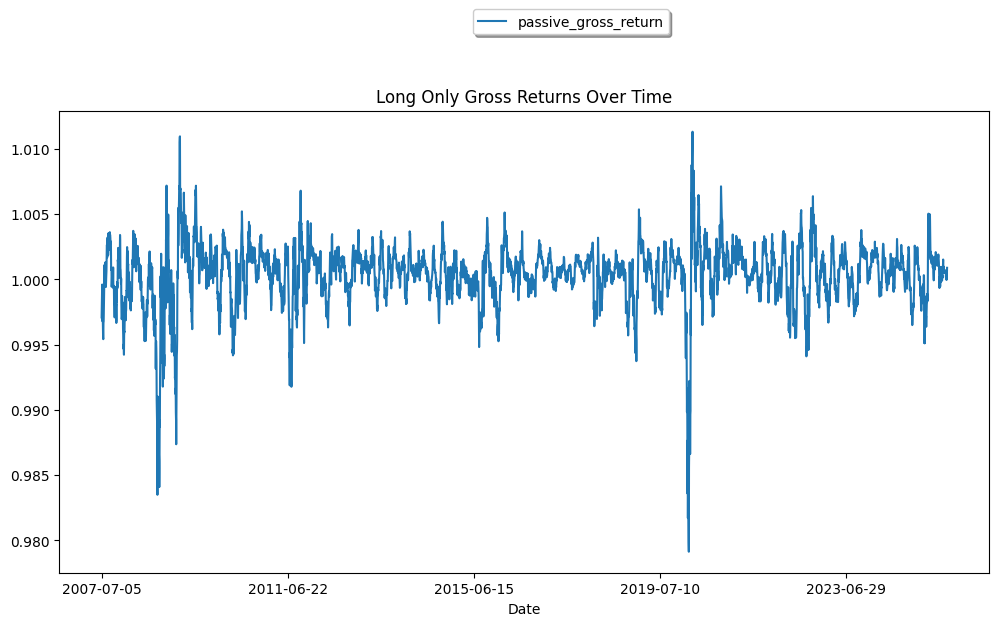

In [ ]:
ax = longonly_daily_return.plot(figsize=(12,6), 
                             title='Long Only Gross Returns Over Time')

(
    ax
    .legend(
        loc="lower center",
        bbox_to_anchor = (0.55, 1.15),
        ncol=4,
        shadow=True
    )
);

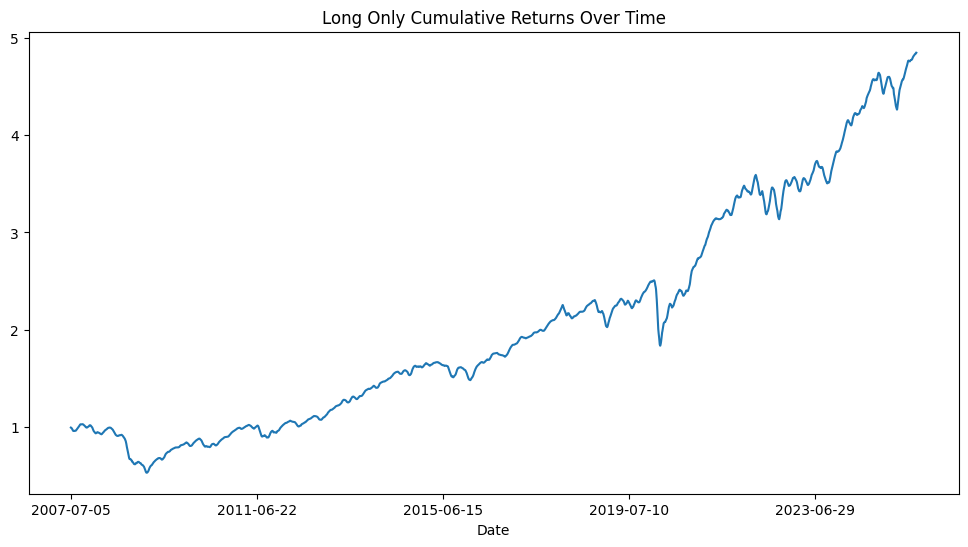

In [ ]:
long_only_cum_returns = \
longonly_daily_return.cumprod()
long_only_cum_returns.plot(figsize=(12,6), title='Long Only Cumulative Returns Over Time');

## Xgboost

In [ ]:
xg_df

,Date,Ticker,market_cap,industry,forward_return,alpha001_short_neut,alpha002_short_neut,alpha003_short_neut,alpha004_short_neut,alpha005_short_neut,...,alpha095_long_neut,alpha096_long_neut,alpha098_long_neut,alpha099_long_neut,alpha101_long_neut,gross_return,passive_gross_return,pred,signal,strategy_return
0,2007-07-05,XLB,8.933808e+08,Buildings,-0.076442,1.411748,-1.625783,0.956192,-0.292917,0.170787,...,0.0,0.173201,-0.241645,0.974769,-1.370677,1.000000,0.923558,0.009776,0.0,-0.000000
1,2007-07-05,XLE,2.646477e+09,Energy,-0.075762,0.076136,0.448342,-1.266076,0.501519,-0.670297,...,0.0,1.067609,-0.538859,0.703958,-0.047309,1.000000,0.924238,0.005382,0.0,-0.000000
2,2007-07-05,XLF,1.258812e+09,Financials,-0.125954,-0.145510,1.120156,0.354751,-0.075911,0.281387,...,0.0,0.826776,-1.225413,-1.433728,0.155030,1.000000,0.874046,-0.000668,0.0,-0.000000
3,2007-07-05,XLI,9.829422e+08,Industrials,-0.016332,-0.278547,1.096118,-1.301561,-0.740698,0.980186,...,0.0,-1.309976,1.870743,1.545290,1.801684,0.934671,0.983668,0.012345,4.0,-0.065329
4,2007-07-05,XLK,1.810529e+09,Technology,-0.030593,1.624089,-0.612057,1.531884,-1.692570,1.705156,...,0.0,-0.571898,0.579604,0.316972,0.081805,1.000000,0.969407,0.011012,0.0,-0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36355,2025-08-29,XLI,2.321119e+10,Industrials,0.028608,-0.444609,0.878849,0.912622,0.608348,0.859369,...,0.0,-1.836267,-0.364463,0.736337,-0.364135,1.000000,1.028608,0.002105,0.0,0.000000
36356,2025-08-29,XLK,8.385155e+10,Technology,0.086306,1.120273,0.492268,0.527971,-1.133770,-1.242745,...,0.0,-0.191464,0.792900,0.636267,0.559123,0.654777,1.086306,-0.009199,-4.0,-0.345223
36357,2025-08-29,XLP,1.570265e+10,Consumer Staples,-0.021602,1.402842,-0.441724,-2.020687,1.306245,0.433151,...,0.0,1.988351,-1.355408,-2.248704,0.800856,1.000000,0.978398,-0.008477,0.0,-0.000000
36358,2025-08-29,XLU,2.090339e+10,Utilities,0.044705,-1.952556,-0.953328,-0.543341,0.849532,1.666059,...,0.0,0.394883,-0.531576,0.141252,-1.603777,1.000000,1.044705,0.002227,0.0,0.000000


<Axes: title={'center': 'XGBoost Strategy Cumulative Returns Over Time'}, xlabel='Date'>

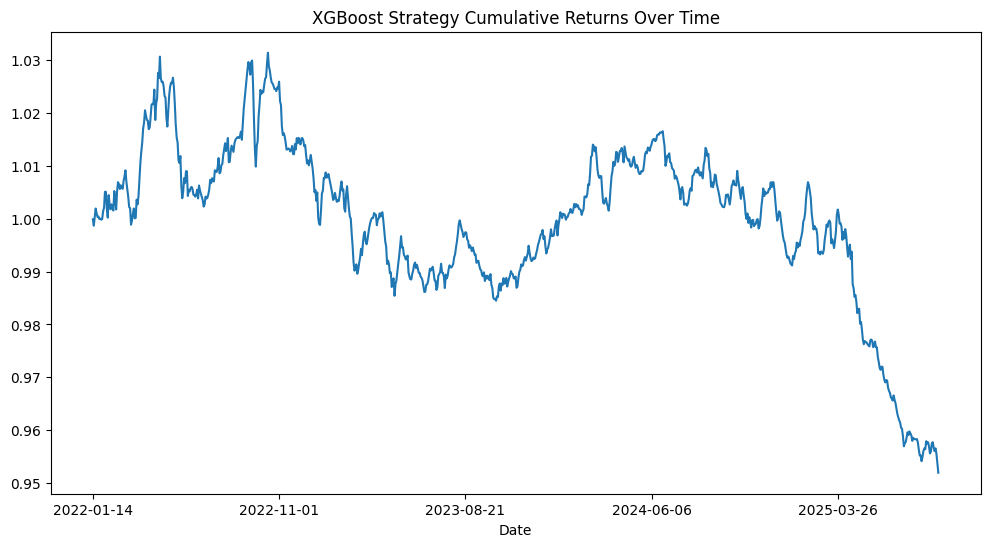

In [ ]:
# xg_strategy_returns.iloc[splitter//len(tickers):].plot(figsize=(12,6), title='XGBoost Strategy Daily Returns Over Time')
xg_gross_returns =\
      xg_df.iloc[train_end:].groupby('Date')['gross_return'].mean() ** (1 / HORIZON)
xg_cum_returns =\
      xg_gross_returns.cumprod()

xg_cum_returns.plot(figsize=(12,6), title='XGBoost Strategy Cumulative Returns Over Time')

## LightGB Model


<Axes: title={'center': 'LightGBM Strategy Cumulative Returns Over Time'}, xlabel='Date'>

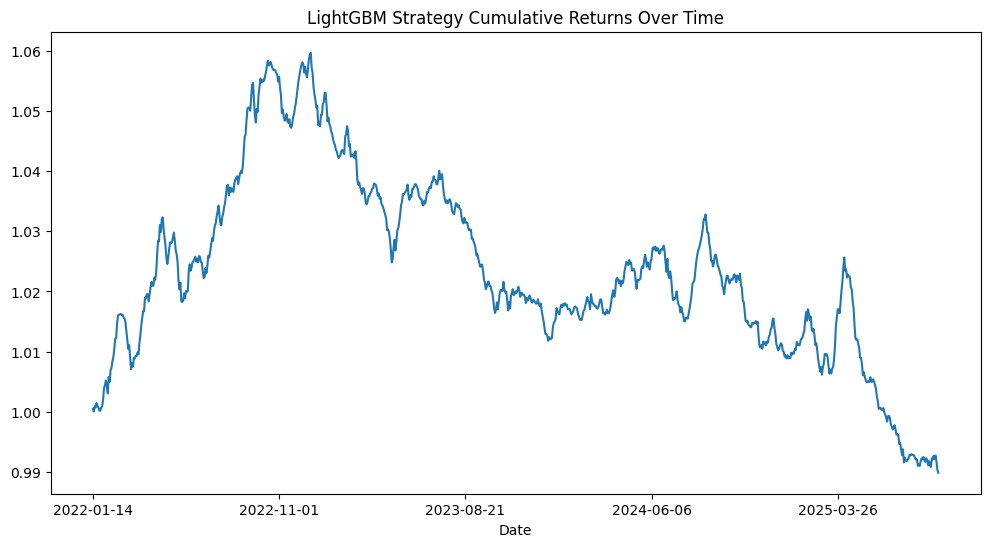

In [ ]:
lg_gross_returns =\
      lgb_df.iloc[train_end:].groupby('Date')['gross_return'].mean() ** (1 / HORIZON)
lg_cum_returns =\
      lg_gross_returns.cumprod()
lg_cum_returns.plot(figsize=(12,6), title='LightGBM Strategy Cumulative Returns Over Time')

In [ ]:
def get_sharpe_ratio(gross_returns, window=1):
    ret = gross_returns - 1
    avg_ret = ret.mean()
    std_ret = ret.std()
    sharpe_ratio = avg_ret / std_ret * np.sqrt(252)
    return sharpe_ratio

def get_cagr(daily_returns, periods_per_year=365):
    cumulative_return = daily_returns.cumprod()
    cumulative_return.index = pd.to_datetime(cumulative_return.index)
    cagr = (cumulative_return.iloc[-1]) ** (periods_per_year / (cumulative_return.index[-1] - cumulative_return.index[0]).days) - 1
    return cagr

dct = {
    'naive': naive_daily_return,
    'long_only': longonly_daily_return,
    'xg': xg_gross_returns,
    'lg': lg_gross_returns
}



compiled_returns = pd.Series({k: get_cagr(v) for k, v in dct.items()}).to_frame("CAGR")
compiled_sharpe = pd.Series({ k: get_sharpe_ratio(v) for k, v in dct.items()}).to_frame("Sharpe Ratio")

display(compiled_returns)
display(compiled_sharpe)

,CAGR
naive,-0.899460
long_only,0.090748
xg,-0.013498
lg,-0.002815


,Sharpe Ratio
naive,-2.788227
long_only,2.337640
xg,-0.591620
lg,-0.173473
